180-degree phase shift frequency: 64.9747 Hz
A matrix shape: (8, 8)
Number of Pauli terms: 24


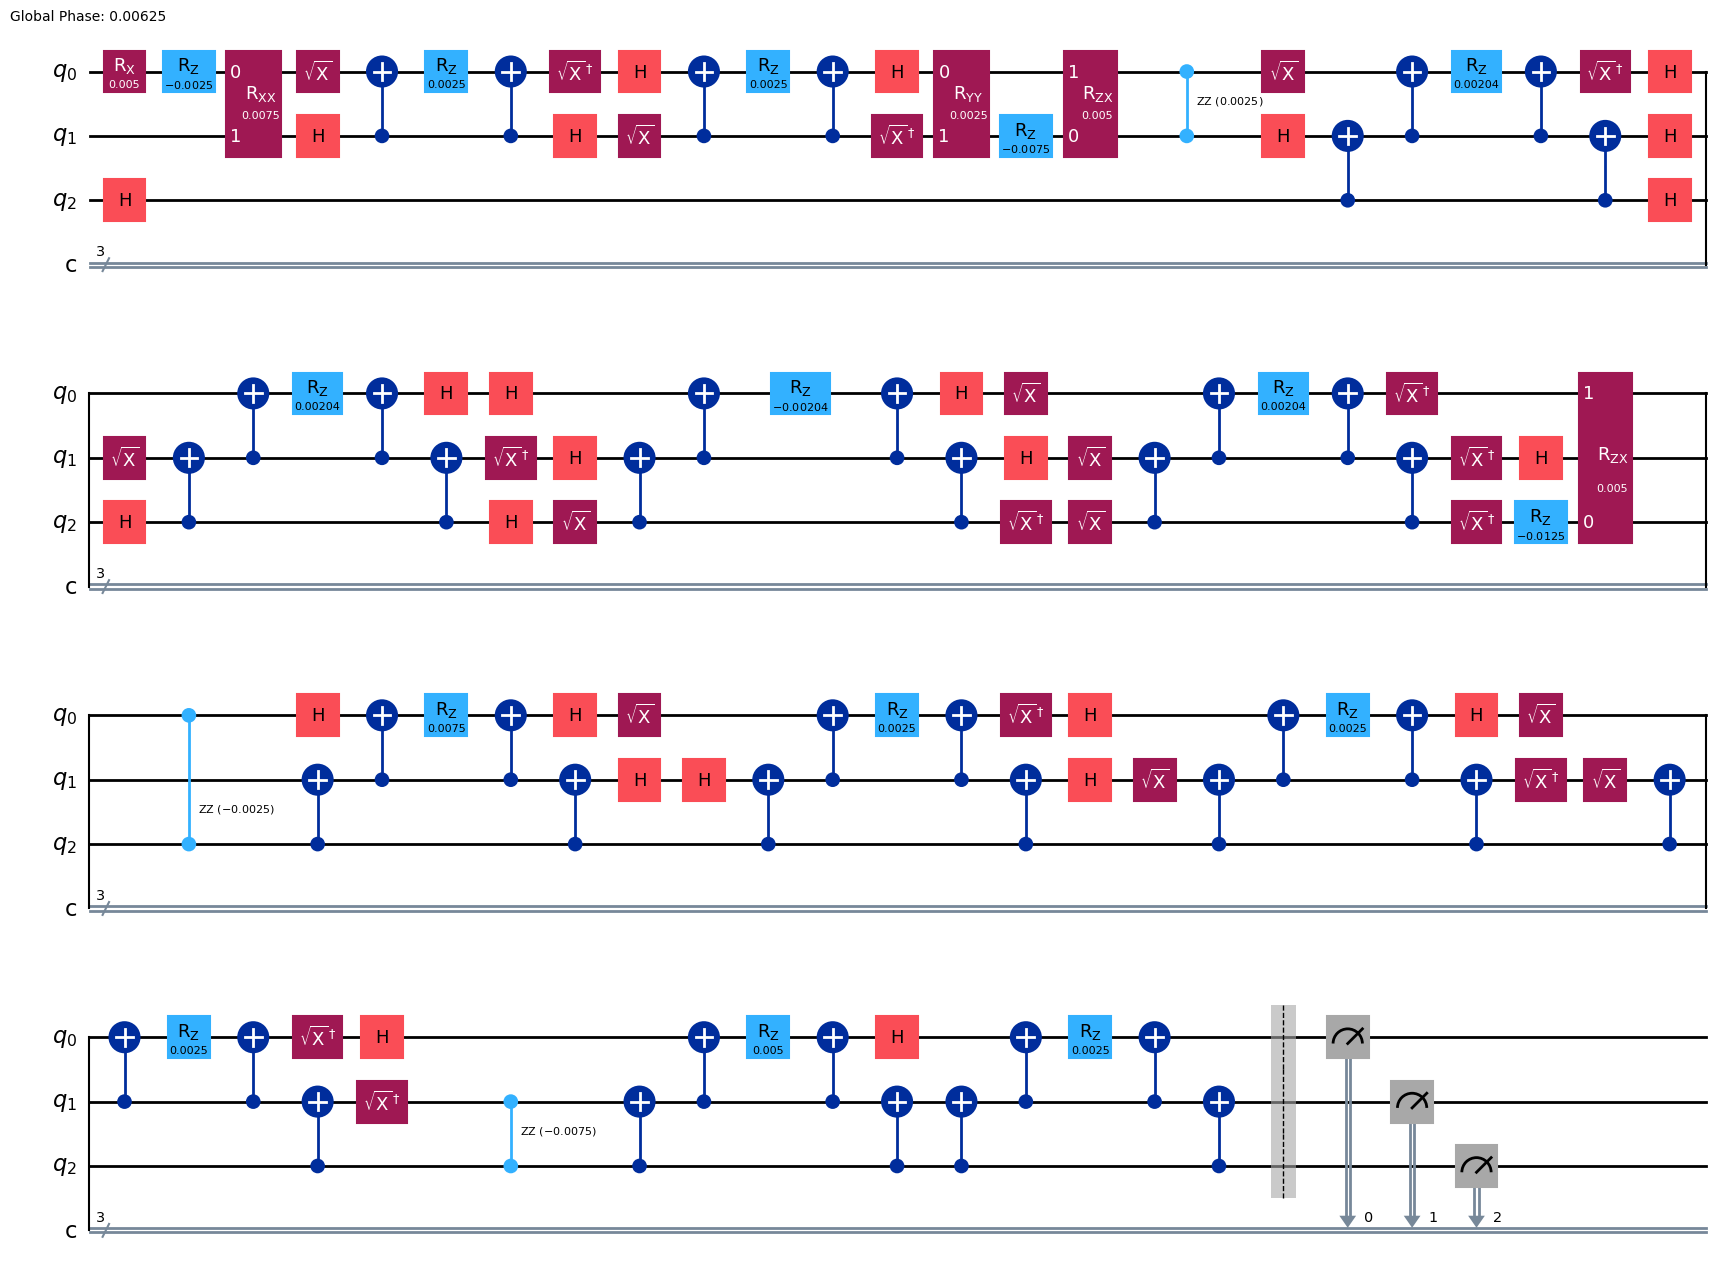

Matrix Difference (Frobenius norm): 1.53e-04
Average Observable Fidelity: 0.195718
Measured Phase Shift at Vc3: -36.5 degrees


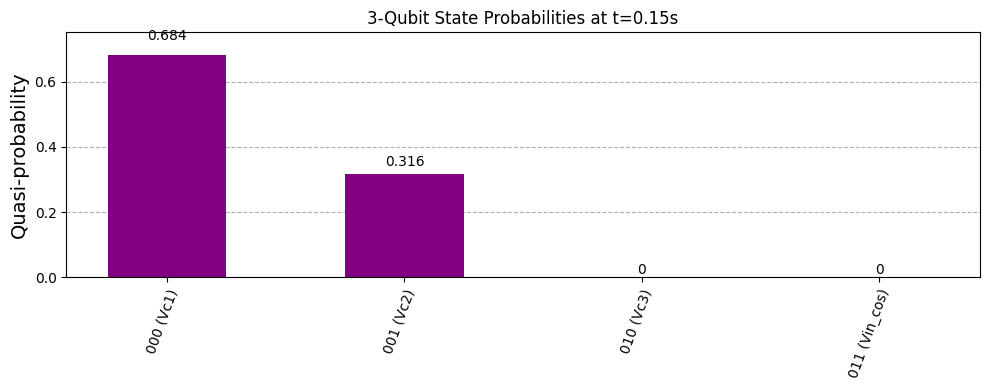

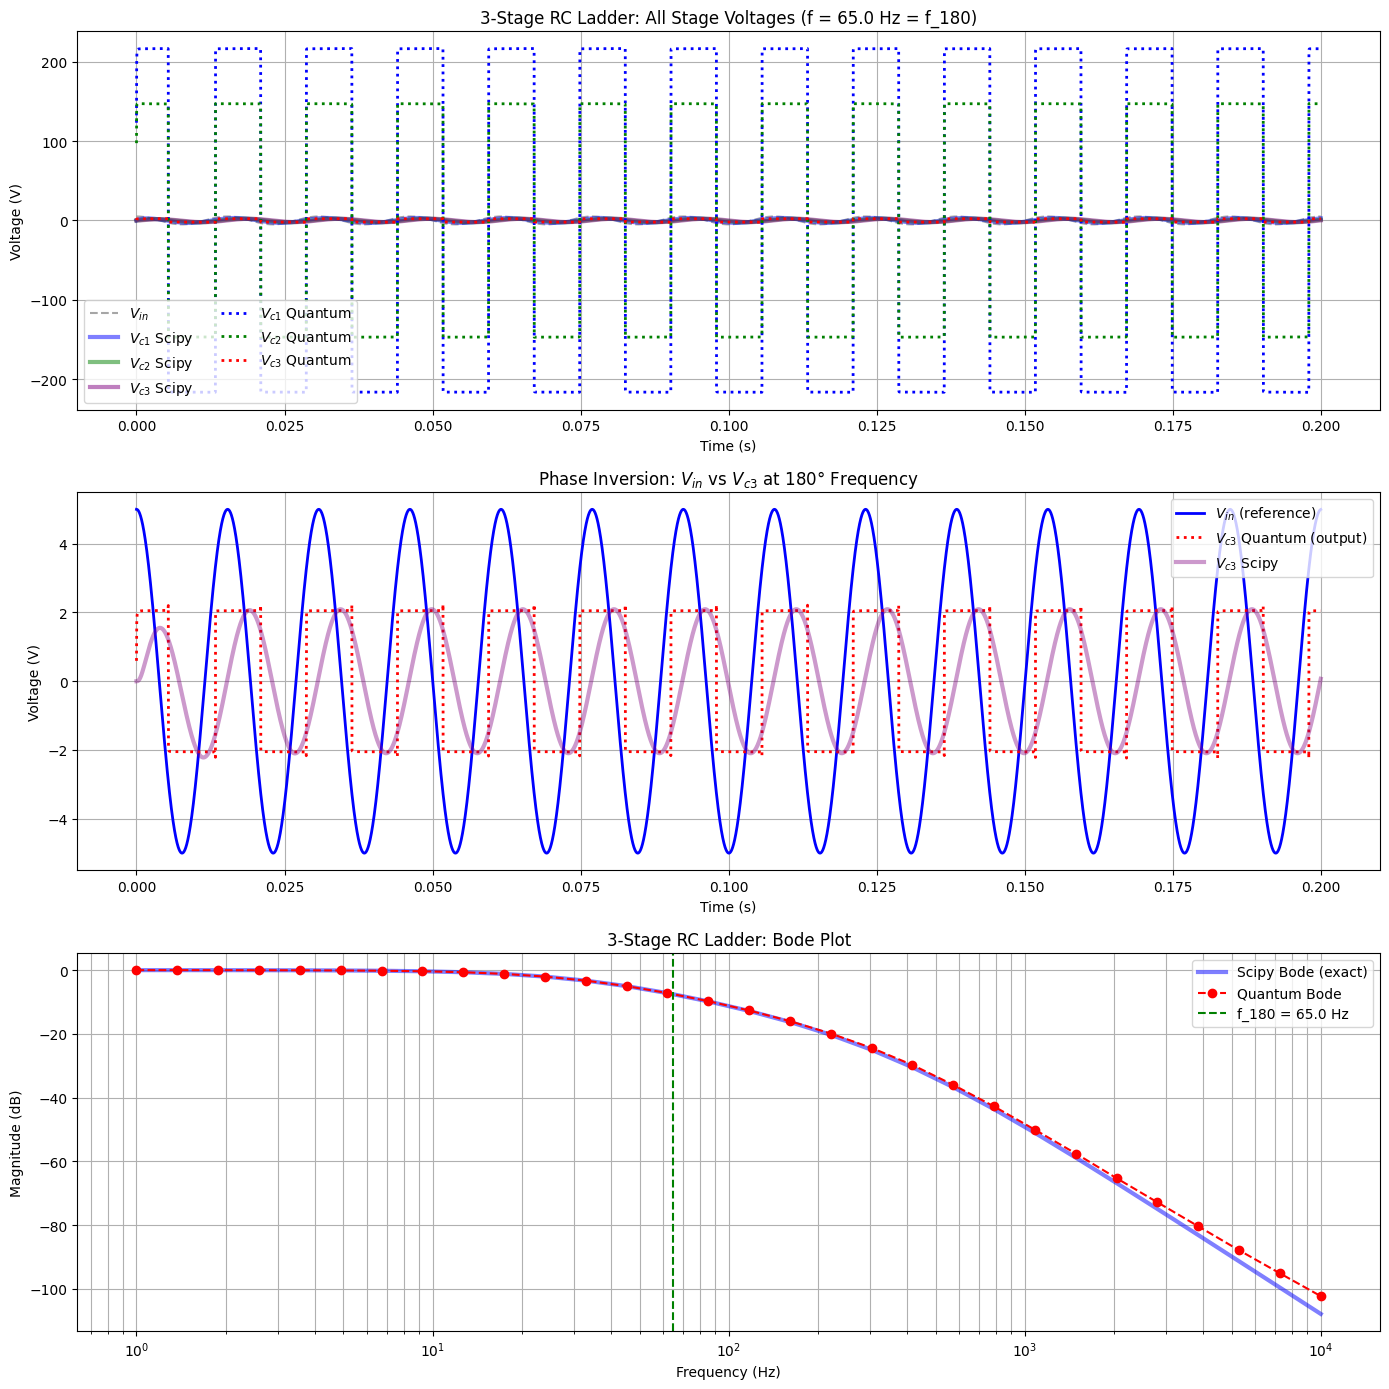

In [1]:
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import scipy.signal as signal
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit.visualization import plot_histogram
from IPython.display import display

# ==========================================
# 1. System Parameters
# ==========================================
R = 1000.0
C = 1e-6
tau = R * C

# The EXACT frequency for 180-degree phase shift
# in a passive 3-stage RC ladder
f180 = 1 / (2 * np.pi * R * C * np.sqrt(6))
f = f180                          # Drive at this frequency
omega = 2 * np.pi * f
V0 = 5.0

print(f"180-degree phase shift frequency: {f180:.4f} Hz")
# For R=1kΩ, C=1µF → f180 ≈ 65.0 Hz

t_max = 0.2                       # Longer sim — lower frequency needs more time
dt = 0.00001
times = np.arange(0, t_max, dt)
target_time = 0.15
target_step = int(target_time / dt)

# ==========================================
# 2. NEW 8x8 A Matrix (3-stage passive ladder)
# ==========================================
A_matrix = np.zeros((8, 8))

# Vc1 row — driven by Vin, coupled to Vc2
A_matrix[0, 0] = -2 / tau
A_matrix[0, 1] =  1 / tau
A_matrix[0, 3] =  1 / tau    # coupling to Vin_cos column

# Vc2 row — coupled to Vc1 and Vc3
A_matrix[1, 0] =  1 / tau
A_matrix[1, 1] = -2 / tau
A_matrix[1, 2] =  1 / tau

# Vc3 row — only coupled to Vc2
A_matrix[2, 1] =  1 / tau
A_matrix[2, 2] = -1 / tau

# AC source oscillator block (rows/cols 3,4)
A_matrix[3, 4] = -omega
A_matrix[4, 3] =  omega

# Rows 5,6,7 are zero (dummy padding to reach 8 = 2^3)

print("A matrix shape:", A_matrix.shape)   # Should be (8,8) → 3 qubits

# ==========================================
# 3. Pauli Decomposition (now 3-qubit, 64 Pauli terms)
# ==========================================
pauli_op = SparsePauliOp.from_operator(Operator(A_matrix))
print(f"Number of Pauli terms: {len(pauli_op)}")  # Will be more than 2-qubit case

# ==========================================
# 4. Quantum Circuit (now 3 qubits)
# ==========================================
visual_paulis, visual_coeffs = [], []
for pauli, coeff in zip(pauli_op.paulis, pauli_op.coeffs):
    if np.abs(coeff) > 1e-10:
        visual_paulis.append(str(pauli))
        visual_coeffs.append(
            np.real(coeff) if np.abs(np.real(coeff)) > 1e-10 else np.imag(coeff)
        )

visual_op = SparsePauliOp(visual_paulis, coeffs=visual_coeffs)
evo_gate = PauliEvolutionGate(visual_op, time=dt)
trotter_step_circuit = LieTrotter().synthesize(evo_gate)

qc = QuantumCircuit(3, 3)          # 3 qubits, 3 classical bits
qc.compose(trotter_step_circuit, inplace=True)
qc.barrier()
qc.measure([0, 1, 2], [0, 1, 2])
display(qc.draw(output='mpl', style='iqp'))

# ==========================================
# 5. Matrix Verification
# ==========================================
circuit_no_meas = qc.remove_final_measurements(inplace=False)
circuit_matrix = Operator(circuit_no_meas).data
exact_matrix_exp = scipy.linalg.expm(-1j * visual_op.to_matrix() * dt)
difference = np.linalg.norm(circuit_matrix - exact_matrix_exp)
print(f"Matrix Difference (Frobenius norm): {difference:.2e}")

# ==========================================
# 6. Scipy Ground Truth (3-stage ODE)
# ==========================================
def rc3_deriv(state, t):
    Vc1, Vc2, Vc3 = state
    Vin = V0 * np.cos(omega * t)
    dVc1 = (Vin - Vc1) / tau - (Vc1 - Vc2) / tau   # = (-2Vc1 + Vc2 + Vin)/tau
    dVc2 = (Vc1 - Vc2) / tau - (Vc2 - Vc3) / tau   # = (Vc1 - 2Vc2 + Vc3)/tau
    dVc3 = (Vc2 - Vc3) / tau                         # = (Vc2 - Vc3)/tau
    return [dVc1, dVc2, dVc3]

scipy_sol = odeint(rc3_deriv, [0.0, 0.0, 0.0], times)
Vc1_scipy = scipy_sol[:, 0]
Vc2_scipy = scipy_sol[:, 1]
Vc3_scipy = scipy_sol[:, 2]
Vin_scipy  = V0 * np.cos(omega * times)

# ==========================================
# 7. Quantum Time Evolution (8D state vector)
# ==========================================
trotter_step_op = np.eye(8, dtype=complex)
for pauli in pauli_op:
    coeff = pauli.coeffs[0]
    matrix = pauli.to_matrix()
    trotter_step_op = scipy.linalg.expm(coeff * matrix * dt) @ trotter_step_op

# Initial state: [Vc1=0, Vc2=0, Vc3=0, Vin_cos=V0, Vin_sin=0, 0, 0, 0]
state_vector = np.array([0.0, 0.0, 0.0, V0, 0.0, 0.0, 0.0, 0.0], dtype=complex)

Vc1_q, Vc2_q, Vc3_q = [], [], []
fidelities = []
target_probabilities = {}

for i, t in enumerate(times):
    state_vector = trotter_step_op @ state_vector
    norm = np.linalg.norm(state_vector)
    if norm > 0:
        state_vector = state_vector / norm

    # Phase correction using Vc3 reference (our output of interest)
    exact_vector = np.array([
        Vc1_scipy[i], Vc2_scipy[i], Vc3_scipy[i],
        V0*np.cos(omega*t), V0*np.sin(omega*t),
        0.0, 0.0, 0.0
    ])
    exact_norm = np.linalg.norm(exact_vector)
    exact_vector_norm = exact_vector / exact_norm if exact_norm > 0 else exact_vector

    overlap = np.vdot(exact_vector_norm, state_vector)
    global_phase = np.angle(overlap)
    corrected_state = state_vector * np.exp(-1j * global_phase)

    # Reconstruct all 3 voltages using the known Vin amplitude as scale reference
    mag_03 = np.abs(corrected_state[3])   # Vin_cos component
    mag_04 = np.abs(corrected_state[4])   # Vin_sin component
    input_prob_mag = np.sqrt(mag_03**2 + mag_04**2)
    scale_factor = (V0 / input_prob_mag) if input_prob_mag > 0 else 0

    Vc1_q.append(scale_factor * np.real(corrected_state[0]))
    Vc2_q.append(scale_factor * np.real(corrected_state[1]))
    Vc3_q.append(scale_factor * np.real(corrected_state[2]))

    # Fidelity
    fidelity = (np.dot(np.abs(exact_vector_norm), np.abs(state_vector)))**2
    fidelities.append(fidelity)

    if i == target_step:
        target_probabilities = {
            '000 (Vc1)':     np.abs(corrected_state[0])**2,
            '001 (Vc2)':     np.abs(corrected_state[1])**2,
            '010 (Vc3)':     np.abs(corrected_state[2])**2,
            '011 (Vin_cos)': np.abs(corrected_state[3])**2,
            '100 (Vin_sin)': np.abs(corrected_state[4])**2,
        }

print(f"Average Observable Fidelity: {np.mean(fidelities):.6f}")

# ==========================================
# 8. Phase Shift Verification
# ==========================================
# Check phase difference between Vin and Vc3 at steady state
# Use last 2 full cycles for steady-state analysis
ss_start = int(0.8 * len(times))
vin_ss  = Vin_scipy[ss_start:]
vc3_ss  = np.array(Vc3_q[ss_start:])
times_ss = times[ss_start:]

# Cross-correlate to find phase lag
correlation = np.correlate(vin_ss / np.max(np.abs(vin_ss)),
                           vc3_ss / np.max(np.abs(vc3_ss)), mode='full')
lag_samples = np.argmax(correlation) - (len(vin_ss) - 1)
phase_shift_deg = (lag_samples * dt * f * 360)
print(f"Measured Phase Shift at Vc3: {phase_shift_deg:.1f} degrees")

# ==========================================
# 9. Histogram
# ==========================================
clean_probs = {k: float(v) for k, v in target_probabilities.items() if v > 1e-10}
display(plot_histogram(clean_probs,
                       title=f"3-Qubit State Probabilities at t={target_time}s",
                       color='purple', figsize=(10, 4)))

# ==========================================
# 10. Final Plots
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: All 3 capacitor voltages + input
ax1 = axes[0]
ax1.plot(times, Vin_scipy, label='$V_{in}$', color='gray', linestyle='--', alpha=0.7)
ax1.plot(times, Vc1_scipy, label='$V_{c1}$ Scipy', color='blue',   linewidth=3, alpha=0.5)
ax1.plot(times, Vc2_scipy, label='$V_{c2}$ Scipy', color='green',  linewidth=3, alpha=0.5)
ax1.plot(times, Vc3_scipy, label='$V_{c3}$ Scipy', color='purple', linewidth=3, alpha=0.5)
ax1.plot(times, Vc1_q,     label='$V_{c1}$ Quantum', color='blue',   linestyle=':', linewidth=2)
ax1.plot(times, Vc2_q,     label='$V_{c2}$ Quantum', color='green',  linestyle=':', linewidth=2)
ax1.plot(times, Vc3_q,     label='$V_{c3}$ Quantum', color='red',    linestyle=':', linewidth=2)
ax1.set_title(f'3-Stage RC Ladder: All Stage Voltages (f = {f:.1f} Hz = f_180)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)')
ax1.legend(ncol=2)
ax1.grid(True)

# Plot 2: Just Vin vs Vc3 to show the 180-degree inversion
ax2 = axes[1]
ax2.plot(times, Vin_scipy, label='$V_{in}$ (reference)', color='blue',  linewidth=2)
ax2.plot(times, Vc3_q,     label='$V_{c3}$ Quantum (output)', color='red', linestyle=':', linewidth=2)
ax2.plot(times, Vc3_scipy, label='$V_{c3}$ Scipy',    color='purple', linewidth=3, alpha=0.4)
ax2.set_title('Phase Inversion: $V_{in}$ vs $V_{c3}$ at 180° Frequency')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Voltage (V)')
ax2.legend()
ax2.grid(True)

# Plot 3: Bode Plot (frequency sweep)
ax3 = axes[2]
quantum_freqs = np.logspace(0, 4, 30)
quantum_mag_db = []
quantum_phase_deg = []

for freq_i in quantum_freqs:
    w_i = 2 * np.pi * freq_i
    A_i = np.zeros((8, 8))
    A_i[0, 0] = -2/tau;  A_i[0, 1] = 1/tau;  A_i[0, 3] = 1/tau
    A_i[1, 0] =  1/tau;  A_i[1, 1] = -2/tau; A_i[1, 2] = 1/tau
    A_i[2, 1] =  1/tau;  A_i[2, 2] = -1/tau
    A_i[3, 4] = -w_i;    A_i[4, 3] =  w_i

    trotter_sweep_op = scipy.linalg.expm(A_i * dt)
    period = 1.0 / freq_i
    sim_time = max(6 * tau, 2.0 * period)
    steps_ss = int(sim_time / dt)
    steps_1_cycle = int(period / dt)
    check_start = steps_ss - steps_1_cycle

    state_ss = np.array([0, 0, 0, V0, 0, 0, 0, 0], dtype=complex)
    vc3_trace = []

    for step in range(steps_ss):
        state_ss = trotter_sweep_op @ state_ss
        sn = np.linalg.norm(state_ss)
        if sn > 0:
            state_ss = state_ss / sn
        if step >= check_start:
            m3, m4 = np.abs(state_ss[3]), np.abs(state_ss[4])
            inp = np.sqrt(m3**2 + m4**2)
            if inp > 0:
                vc3_trace.append((V0 / inp) * np.abs(state_ss[2]))

    if vc3_trace:
        quantum_mag_db.append(20 * np.log10(max(vc3_trace) / V0 + 1e-12))
    else:
        quantum_mag_db.append(-100)

# Scipy theoretical Bode for 3-stage RC
# Transfer function: H(s) = 1 / (1 + 5RCs + 6(RC)^2 s^2 + (RC)^3 s^3)
# ... using signal.bode for exact answer
num = [1]
den = [(tau**3), 5*(tau**2), 6*tau, 1]  # 3-stage passive RC transfer function
sys3 = signal.TransferFunction(num, den)
w_bode, mag_bode, phase_bode = signal.bode(sys3, w=quantum_freqs * 2 * np.pi)

ax3.semilogx(quantum_freqs, mag_bode,        label='Scipy Bode (exact)',   color='blue', linewidth=3, alpha=0.5)
ax3.semilogx(quantum_freqs, quantum_mag_db,  label='Quantum Bode',         color='red',  marker='o', linestyle='--')
ax3.axvline(x=f180, color='green', linestyle='--', label=f'f_180 = {f180:.1f} Hz')
ax3.set_title('3-Stage RC Ladder: Bode Plot')
ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylabel('Magnitude (dB)')
ax3.legend()
ax3.grid(True, which='both')

plt.tight_layout()
plt.show()